In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
.inner_cell{font-size:20pt;}
div.text_cell_render pre code {font-size:20pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:18px;}
</style>
"""))

# 딥러닝 : 데이터의 규칙성을 추출
- 응용분야 : 글씨인식, 문장분류, 값예측, 질병진단, 얼굴인식
- ML/DL의 종류
    * 지도학습(입력=독립변수, 타겟=종속변수)
        * 분류분석(타겟변수가 category변수인 분석. 다중분류와 이진분류) vs 회귀분석
    * 비지도학습(입력변수)
        * 군집화
    * 강화학습
    
- 지도학습에서의 딥러닝 프로그래밍 방식
    - 1. 데이터 확보 및 생성
    - 2. 데이터 전처리 : 결측치처리, 스케일 조정, 인코딩처리(라벨인코딩, 원핫인코딩), 학습,검증,시험데이터셋 분리
    - 3. 모델 구성
    - 4. 모델 학습 과정 설정
    - 5. 모델 학습시키기(훈련, 검증 데이터셋)
    - 6. 모델 평가(시험 데이터셋)
    - 7. 모델 저장/사용(입력값이 주어지면 예측값을 받기)

In [2]:
from tensorflow.keras.utils import to_categorical # 분류분석시 원핫인코딩(to_categorical추천)
import pandas as pd # 원핫인코딩
from tensorflow.keras.models import Sequential, load_model # 모델 생성, 모델 load
from tensorflow.keras.layers import Dense, Input # 모델에 층을 쌓기 위해서
import numpy as np

# 1. 데이터셋 확보
# 2. 데이터 전처리

In [3]:
# 학습데이터 = 훈련데이터셋
x_train = np.array([1,2,3,4,5,6,7,8,9]*10)
y_train = np.array([2,3,4,5,6,7,8,9,10]*10)
# 검증데이터, 시험데이터셋
x_val = np.array([1,2,3,4,5,6,7,8,9])
y_val = np.array([2,3,4,5,6,7,8,9,10])

In [4]:
# 인코딩 종류
    # 라벨인코딩 = 문자를 숫자로
    # 원핫인코딩 = 값의 갯수만큼 열을 만들고, 해당 범주에 해당하는 열만 1을, 나머지열은 0을
data = np.array(['aa','bb','cc','bb','bb'])
print('원 데이터 :', data)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# le.fit(data)
# labeling_data = le.transform(data)
labeling_data = le.fit_transform(data)
print('라벨인코딩된 데이터 :', labeling_data)
# onehot_encoding_data = to_categorical(data) # 에러남
onehot_encoding_data1 = to_categorical(labeling_data)
print('원핫인코딩된 데이터 : \n', onehot_encoding_data1)
onehot_encoding_data2 = pd.get_dummies(data) 
#onehot_encoding_data2 = pd.get_dummies(labeling_data) 
print('원핫인코딩된 데이터 : \n', onehot_encoding_data2)

원 데이터 : ['aa' 'bb' 'cc' 'bb' 'bb']
라벨인코딩된 데이터 : [0 1 2 1 1]
원핫인코딩된 데이터 : 
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]]
원핫인코딩된 데이터 : 
    aa  bb  cc
0   1   0   0
1   0   1   0
2   0   0   1
3   0   1   0
4   0   1   0


In [5]:
data = np.array([1, 4, 5, 4, 5])
categorical_onehot = to_categorical(data)
print('to_categorical 이용 \n', categorical_onehot)
getdummies_onehot = pd.get_dummies(data)
print('get_dummies 이용\n', getdummies_onehot)

to_categorical 이용 
 [[0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]]
get_dummies 이용
    1  4  5
0  1  0  0
1  0  1  0
2  0  0  1
3  0  1  0
4  0  0  1


In [6]:
# 분류분석을 위한 종속(타겟)변수의 원핫인코딩
Y_train = to_categorical(y_train, 11)
Y_val = to_categorical(y_val)

In [7]:
# 딥러닝 모델에 사용될 데이터
x_train.shape, Y_train.shape, x_val.shape, Y_val.shape

((90,), (90, 11), (9,), (9, 11))

# 3. 모델 구성

In [8]:
model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(units=38, activation='sigmoid')) # 활성화함수 : relu, elu, tanh, sigmoid, softmax
model.add(Dense(64, activation='elu'))
model.add(Dense(32, activation='elu'))
model.add(Dense(11, activation='softmax')) # 다중분류에서의 출력층 활성화 함수 : softmax
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 38)                76        
                                                                 
 dense_1 (Dense)             (None, 64)                2496      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 11)                363       
                                                                 
Total params: 5,015
Trainable params: 5,015
Non-trainable params: 0
_________________________________________________________________


# 4. 모델학습과정 설정
- 회귀분석에서의 loss : mse, mae, rmse
- 다중 분류에서의 loss: categorical_crossentropy
- 이진 분류에서의 loss: binary_crossentropy
- 분류분석에서의 metrics(평가지표) : accuracy, recall, precision

In [9]:
model.compile(loss='categorical_crossentropy', 
             optimizer='adam',
             metrics=['accuracy'])

# 5. 모델 학습시키기

In [10]:
hist = model.fit(x_train, Y_train, # 학습데이터셋(입력변수와 타겟변수)
                 epochs=300,       # 학습횟수
                 batch_size=10,
                 validation_data=(x_val, Y_val),
                 verbose=1)
# verbose=0 : 학습로그출력없음/ 1:기본값출력 / 2:자세한로그출력

Epoch 1/300
9/9 [==============================] - 1s 46ms/step - loss: 2.3592 - accuracy: 0.1333 - val_loss: 2.2515 - val_accuracy: 0.2222
Epoch 2/300
9/9 [==============================] - 0s 5ms/step - loss: 2.2187 - accuracy: 0.1444 - val_loss: 2.1513 - val_accuracy: 0.3333
Epoch 3/300
9/9 [==============================] - 0s 5ms/step - loss: 2.1218 - accuracy: 0.2222 - val_loss: 2.0698 - val_accuracy: 0.3333
Epoch 4/300
9/9 [==============================] - 0s 5ms/step - loss: 2.0457 - accuracy: 0.2444 - val_loss: 1.9954 - val_accuracy: 0.3333
Epoch 5/300
9/9 [==============================] - 0s 5ms/step - loss: 1.9748 - accuracy: 0.3333 - val_loss: 1.9223 - val_accuracy: 0.4444
Epoch 6/300
9/9 [==============================] - 0s 6ms/step - loss: 1.8979 - accuracy: 0.3889 - val_loss: 1.8509 - val_accuracy: 0.4444
Epoch 7/300
9/9 [==============================] - 0s 5ms/step - loss: 1.8321 - accuracy: 0.4111 - val_loss: 1.7815 - val_accuracy: 0.3333
Epoch 8/300
9/9 [=========

9/9 [==============================] - 0s 5ms/step - loss: 0.0642 - accuracy: 1.0000 - val_loss: 0.0617 - val_accuracy: 1.0000
Epoch 118/300
9/9 [==============================] - 0s 5ms/step - loss: 0.0624 - accuracy: 1.0000 - val_loss: 0.0580 - val_accuracy: 1.0000
Epoch 119/300
9/9 [==============================] - 0s 5ms/step - loss: 0.0583 - accuracy: 1.0000 - val_loss: 0.0559 - val_accuracy: 1.0000
Epoch 120/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0569 - accuracy: 1.0000 - val_loss: 0.0545 - val_accuracy: 1.0000
Epoch 121/300
9/9 [==============================] - 0s 6ms/step - loss: 0.0551 - accuracy: 1.0000 - val_loss: 0.0532 - val_accuracy: 1.0000
Epoch 122/300
9/9 [==============================] - 0s 6ms/step - loss: 0.0526 - accuracy: 1.0000 - val_loss: 0.0510 - val_accuracy: 1.0000
Epoch 123/300
9/9 [==============================] - 0s 5ms/step - loss: 0.0515 - accuracy: 1.0000 - val_loss: 0.0497 - val_accuracy: 1.0000
Epoch 124/300
9/9 [========

9/9 [==============================] - 0s 6ms/step - loss: 0.0057 - accuracy: 1.0000 - val_loss: 0.0056 - val_accuracy: 1.0000
Epoch 234/300
9/9 [==============================] - 0s 5ms/step - loss: 0.0056 - accuracy: 1.0000 - val_loss: 0.0055 - val_accuracy: 1.0000
Epoch 235/300
9/9 [==============================] - 0s 5ms/step - loss: 0.0056 - accuracy: 1.0000 - val_loss: 0.0055 - val_accuracy: 1.0000
Epoch 236/300
9/9 [==============================] - 0s 6ms/step - loss: 0.0055 - accuracy: 1.0000 - val_loss: 0.0054 - val_accuracy: 1.0000
Epoch 237/300
9/9 [==============================] - 0s 6ms/step - loss: 0.0054 - accuracy: 1.0000 - val_loss: 0.0053 - val_accuracy: 1.0000
Epoch 238/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0053 - accuracy: 1.0000 - val_loss: 0.0052 - val_accuracy: 1.0000
Epoch 239/300
9/9 [==============================] - 0s 6ms/step - loss: 0.0052 - accuracy: 1.0000 - val_loss: 0.0052 - val_accuracy: 1.0000
Epoch 240/300
9/9 [========

# 6. 모델 평가하기(모델 학습과정 살펴보고, evaluate)

In [11]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

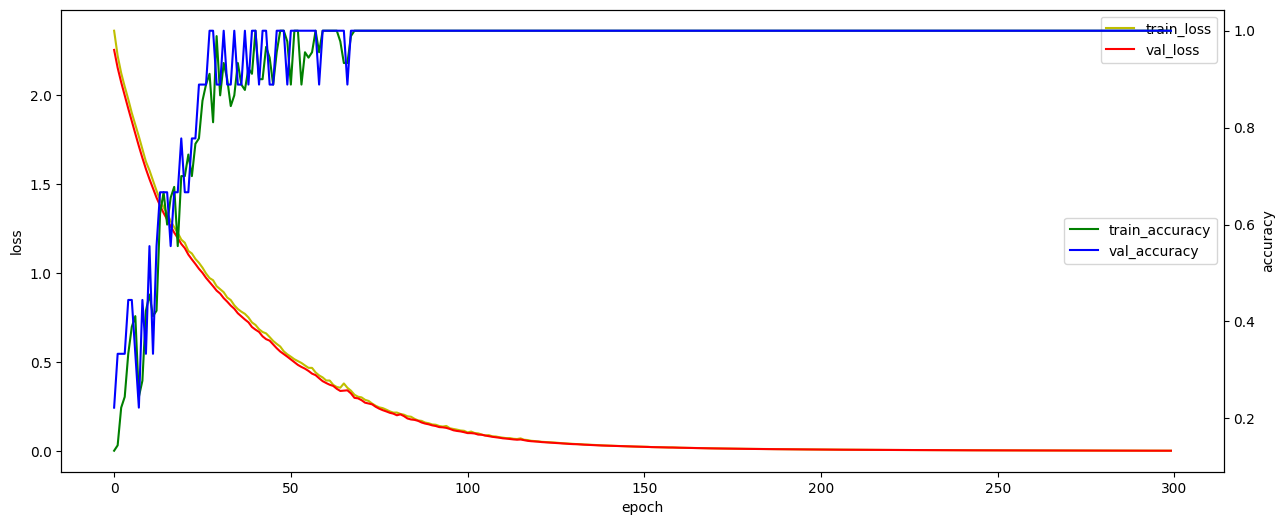

In [12]:
# 학습과정 살펴보기
import matplotlib.pyplot as plt
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper right')
acc_ax.legend(loc='center right')
plt.show()

In [14]:
# 모델 평가하기
score = model.evaluate(x_val, Y_val, batch_size=3)
print('loss : ', score[0])
print('accuracy : ', score[1])

3/3 [==============================] - 0s 3ms/step - loss: 0.0025 - accuracy: 1.0000
loss :  0.0025434817653149366
accuracy :  1.0


# 7. 모델 저장

In [15]:
model.save('model/02_deep.h5') # 모델 저장 파일 : h5이나 keras

In [17]:
# 저장된 모델 사용하기
model1 = load_model('model/02_deep.h5')

# 7. 모델 사용

In [19]:
h = model.predict(np.array([5]))
h.argmax()

1/1 [==============================] - 0s 20ms/step


6

In [20]:
model.predict(np.array([5])).argmax()

1/1 [==============================] - 0s 18ms/step


6

In [22]:
# 몇 %확률로 5라고 예측했나?
h[0, h.argmax()]*100

99.79142546653748

In [25]:
h[0, [5,6,7]]

array([7.0413027e-04, 9.9791425e-01, 1.3815091e-03], dtype=float32)